### **Análisis** de **sensibilidad paramétrica**

Este notebook estudia la influencia de distintos parámetros biológicos sobre la evolución tumoral mediante un análisis de sensibilidad del modelo.

En particular, se analiza el efecto de:

* $a$: tasa de proliferación celular.
* $K$: capacidad de carga del tejido.
* $\gamma$: eficacia citotóxica del tratamiento.

Para cada parámetro se realizan simulaciones variando su valor dentro de un rango predefinido y manteniendo constantes el resto de parámetros. Además, se comparan dos intensidades terapéuticas distintas ($\beta=0.2$) y ($\beta=0.5$) con el fin de evaluar cómo la respuesta del tumor depende simultáneamente de la biología del sistema y de la acción del tratamiento.

Como medida de comparación se utiliza la masa tumoral total al tiempo final de simulación $(T=15)$,

$$
M(T)=\int_{\Omega} c(x,y,T) \, dx \, dy.
$$

Y con el propósito de unificar los hallazgos de los barridos paramétricos y establecer un criterio de comparación cuantitativo directo entre las pendientes locales de las curvas —las cuales poseen distintas naturalezas y unidades físicas—, este código implementa y calcula un indicador original de susceptibilidad estructural denominado Índice de Sensibilidad Normalizado ($\mathcal{S}_p$). Este índice evalúa la elasticidad puntual del sistema aislando numéricamente la derivada diferencial mediante diferencias finitas centrales y adimensionalizándola respecto a los valores basales:

$$
\mathcal{S}_p = \frac{\partial M(T) / M(T)}{\partial p / p} = \frac{\partial M(T)}{\partial p} \cdot \frac{p}{M(T)}
$$

Los resultados finales se estructuran en un gráfico de barras comparativo de pendientes normalizadas, lo que permite identificar qué parámetros ejercen un mayor peso real (sensibilidad) sobre la dinámica tumoral y evaluar la robustez y estabilidad del modelo frente a variaciones en sus valores.

In [11]:
# =====================================================
# LIBRERÍAS Y ENTORNO DEL SISTEMA
# =====================================================
import os
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [12]:
# =====================================================
# CREAR CARPETA EN EL ESCRITORIO
# =====================================================

ruta_escritorio = os.path.join(os.path.expanduser("~"), "Desktop")
ruta_figuras = os.path.join(ruta_escritorio, "TFM_Analisis_Sensibilidad")
os.makedirs(ruta_figuras, exist_ok=True)

In [13]:
# =====================================================
# PARÁMETROS BASALES DE CONTROL (ESTADOS DE REFERENCIA)
# =====================================================

D_basal = 0.01
a_basal = 0.5
K_basal = 1.0
gamma_basal = 1.0

In [14]:
# =====================================================
# DISCRETIZACIÓN ESPACIAL (MALLA BIDIMENSIONAL ÓPTIMA)
# =====================================================

Lx, Ly = 1.0, 1.0
Nx, Ny = 60, 60  
dx, dy = Lx / Nx, Ly / Ny
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y, indexing="ij")

# =====================================================
# PARÁMETROS DE INTEGRACIÓN TEMPORAL (ESTABILIDAD)
# =====================================================

T = 15.0
dt = 2e-4
Nt = int(T / dt)

In [15]:
# =====================================================
# CONDICIÓN INICIAL (FOCO TUMORAL PRIMARIO LOCALIZADO)
# =====================================================

x0, y0, sigma, c0 = 0.5, 0.5, 0.10, 1.0
c_inicial = c0 * np.exp(-((X - x0) ** 2 + (Y - y0) ** 2) / sigma**2)

# =====================================================
# OPERADORES DIFERENCIALES NUMÉRICOS
# =====================================================

def laplaciano(Z):
    return (np.roll(Z, -1, axis=0) - 2 * Z + np.roll(Z, 1, axis=0)) / dx**2 + (
        np.roll(Z, -1, axis=1) - 2 * Z + np.roll(Z, 1, axis=1)
    ) / dy**2
    
# =====================================================
# NÚCLEO DE SIMULACIÓN Y EVALUACIÓN DIRECTA
# =====================================================

def simular_masa_final(D_val, a_val, K_val, gamma_val, beta_estacionaria):
    """
    Simula la ecuación de reacción-difusión con fármaco homogéneo constante
    hasta tiempo T y retorna la masa tumoral total integrada.
    """
    c = c_inicial.copy()
    for _ in range(Nt):
        c_old = c.copy()
        lap = laplaciano(c_old)
        
        # Término reactivo Gompertziano protegido contra indeterminaciones numéricas
        reaction = a_val * c_old * np.log(K_val / (c_old + 1e-12))
        
        # Término citotóxico de interacción lineal
        treatment = gamma_val * c_old * beta_estacionaria
        
        # Actualización temporal del esquema explícito
        c = c_old + dt * (D_val * lap + reaction - treatment)

        # Preservación estricta del principio del máximo físico
        c = np.maximum(c, 0) # Preservación del principio del máximo físico
        
    return np.sum(c) * dx * dy

# =====================================================
# BARRIDO PARAMÉTRICO COMPLETO (3 PARÁMETROS × 2 DOSIS)
# =====================================================
puntos_barrido = 7
valores_a = np.linspace(0.1, 0.9, puntos_barrido)
valores_K = np.linspace(0.5, 1.5, puntos_barrido)
valores_gamma = np.linspace(0.2, 1.8, puntos_barrido)

# Escenarios farmacológicos estacionarios (beta constante en el tejido)
betas_estudio = [0.2, 0.5] 

resultados = {b: {"sens_a": [], "sens_K": [], "sens_gamma": []} for b in betas_estudio}

print("Iniciando análisis de sensibilidad computacional tridimensional...")

for b in betas_estudio:
    print(f"\n-> Procesando entorno bajo presión terapéutica constante beta = {b}")
    
    # Estudio de Sensibilidad 1: Tasa de Proliferación (a)
    for a_aux in tqdm(valores_a, desc="Variando proliferación 'a'"):
        m_f = simular_masa_final(D_basal, a_aux, K_basal, gamma_basal, b)
        resultados[b]["sens_a"].append(m_f)
        
    # Estudio de Sensibilidad 2: Capacidad de Carga (K)
    for K_aux in tqdm(valores_K, desc="Variando capacidad de carga 'K'"):
        m_f = simular_masa_final(D_basal, a_basal, K_aux, gamma_basal, b)
        resultados[b]["sens_K"].append(m_f)
        
    # Estudio de Sensibilidad 3: Eficacia Terapéutica (gamma)
    for g_aux in tqdm(valores_gamma, desc="Variando eficacia 'gamma'"):
        m_f = simular_masa_final(D_basal, a_basal, K_basal, g_aux, b)
        resultados[b]["sens_gamma"].append(m_f)

# Configuración de estilo global para figuras individuales
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

Iniciando análisis de sensibilidad computacional tridimensional...

-> Procesando entorno bajo presión terapéutica constante beta = 0.2


Variando eficacia 'gamma': 100%|██████████| 7/7 [01:25<00:00, 12.22s/it]



-> Procesando entorno bajo presión terapéutica constante beta = 0.5


Variando eficacia 'gamma': 100%|██████████| 7/7 [01:25<00:00, 12.27s/it]


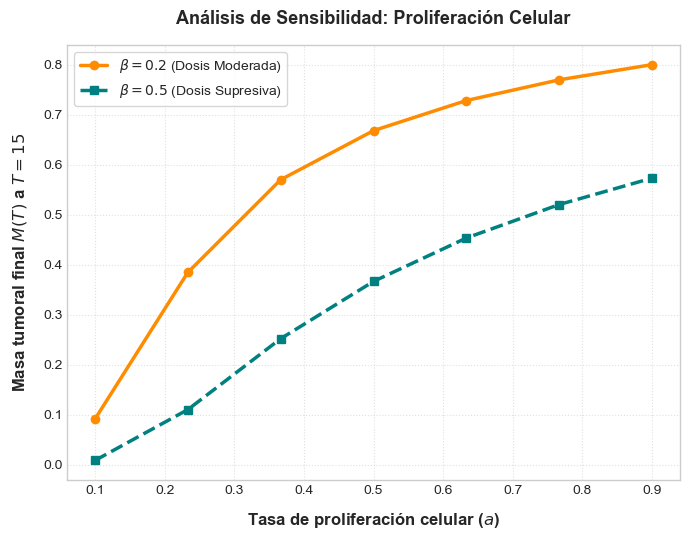

In [16]:
# =====================================================
# GRÁFICA INDEPENDIENTE 1: PROLIFERACIÓN CELULAR
# =====================================================
fig1, ax1 = plt.subplots(figsize=(7, 5.5))
ax1.plot(valores_a, resultados[0.2]["sens_a"], marker='o', ls='-', lw=2.5, color='darkorange', label=r'$\beta = 0.2$ (Dosis Moderada)')
ax1.plot(valores_a, resultados[0.5]["sens_a"], marker='s', ls='--', lw=2.5, color='teal', label=r'$\beta = 0.5$ (Dosis Supresiva)')
ax1.set_xlabel(r'Tasa de proliferación celular ($a$)', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel(r'Masa tumoral final $M(T)$ a $T=15$', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_title('Análisis de Sensibilidad: Proliferación Celular', fontsize=13, fontweight='bold', pad=15)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=10, loc='best', frameon=True)
plt.tight_layout()
ruta_p = os.path.join(ruta_figuras, "sensibilidad_proliferacion.png")
plt.savefig(ruta_p, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

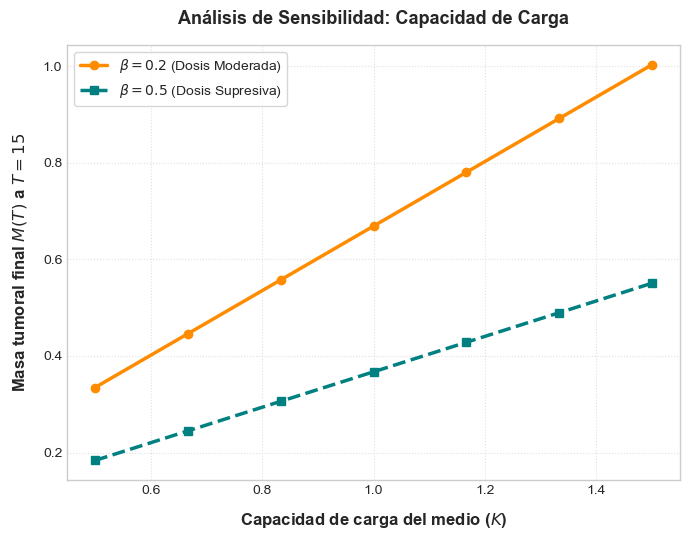

In [17]:
# =====================================================
# GRÁFICA INDEPENDIENTE 2: CAPACIDAD DE CARGA
# =====================================================
fig2, ax2 = plt.subplots(figsize=(7, 5.5))
ax2.plot(valores_K, resultados[0.2]["sens_K"], marker='o', ls='-', lw=2.5, color='darkorange', label=r'$\beta = 0.2$ (Dosis Moderada)')
ax2.plot(valores_K, resultados[0.5]["sens_K"], marker='s', ls='--', lw=2.5, color='teal', label=r'$\beta = 0.5$ (Dosis Supresiva)')
ax2.set_xlabel(r'Capacidad de carga del medio ($K$)', fontsize=12, fontweight='bold', labelpad=10)
ax2.set_ylabel(r'Masa tumoral final $M(T)$ a $T=15$', fontsize=12, fontweight='bold', labelpad=10)
ax2.set_title('Análisis de Sensibilidad: Capacidad de Carga', fontsize=13, fontweight='bold', pad=15)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=10, loc='best', frameon=True)
plt.tight_layout()
ruta_k = os.path.join(ruta_figuras, "sensibilidad_capacidad_carga.png")
plt.savefig(ruta_k, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

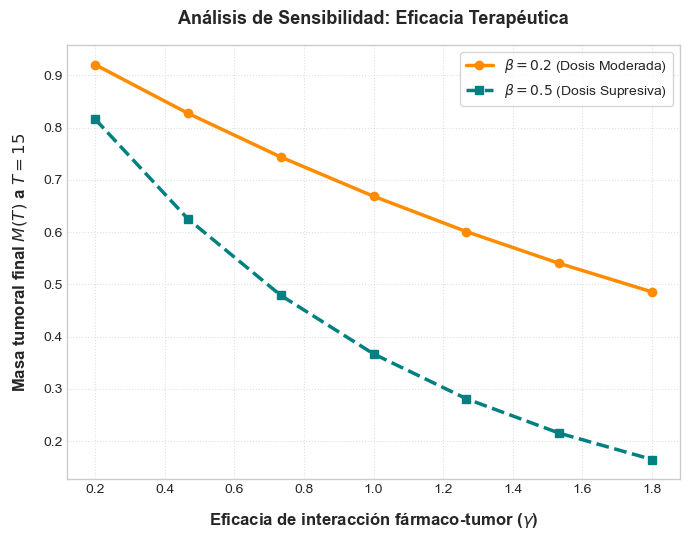


 Las 3 gráficas independientes se han generado y guardado correctamente.


In [18]:
# =====================================================
# GRÁFICA INDEPENDIENTE 3: EFICACIA TERAPÉUTICA
# =====================================================
fig3, ax3 = plt.subplots(figsize=(7, 5.5))
ax3.plot(valores_gamma, resultados[0.2]["sens_gamma"], marker='o', ls='-', lw=2.5, color='darkorange', label=r'$\beta = 0.2$ (Dosis Moderada)')
ax3.plot(valores_gamma, resultados[0.5]["sens_gamma"], marker='s', ls='--', lw=2.5, color='teal', label=r'$\beta = 0.5$ (Dosis Supresiva)')
ax3.set_xlabel(r'Eficacia de interacción fármaco-tumor ($\gamma$)', fontsize=12, fontweight='bold', labelpad=10)
ax3.set_ylabel(r'Masa tumoral final $M(T)$ a $T=15$', fontsize=12, fontweight='bold', labelpad=10)
ax3.set_title('Análisis de Sensibilidad: Eficacia Terapéutica', fontsize=13, fontweight='bold', pad=15)
ax3.grid(True, linestyle=':', alpha=0.6)
ax3.legend(fontsize=10, loc='best', frameon=True)
plt.tight_layout()
ruta_g = os.path.join(ruta_figuras, "sensibilidad_eficacia.png")
plt.savefig(ruta_g, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\n Las 3 gráficas independientes se han generado y guardado correctamente.")

In [19]:
# =====================================================
# CÁLCULO DEL ÍNDICE DE SENSIBILIDAD ADIMENSIONAL
# =====================================================

def calcular_elasticidad_sensibilidad(valores_p, masas_M):
    """
    Calcula el índice de sensibilidad adimensional S_p = (dM/dp) * (p/M).
    Aísla la pendiente local exacta y la normaliza para eliminar unidades físicas.
    """
    valores_p = np.array(valores_p)
    masas_M = np.array(masas_M)
    
    # Paso del barrido discreto
    dp = valores_p[1] - valores_p[0]
    
    # np.gradient calcula la pendiente exacta (derivada dM/dp) en cada punto
    derivada_pendiente = np.gradient(masas_M, dp)
    
    # Índice normalizado de elasticidad
    S_p = derivada_pendiente * (valores_p / masas_M)
    return S_p

# 1. Recuperar los rangos de parámetros basales del notebook
rangos_a = valores_a
rangos_K = valores_K
rangos_g = valores_gamma

# 2. Calcular los perfiles de pendientes normalizadas (Elasticidad puntual)
S_a_02 = calcular_elasticidad_sensibilidad(rangos_a, resultados[0.2]['sens_a'])
S_a_05 = calcular_elasticidad_sensibilidad(rangos_a, resultados[0.5]['sens_a'])

S_K_02 = calcular_elasticidad_sensibilidad(rangos_K, resultados[0.2]['sens_K'])
S_K_05 = calcular_elasticidad_sensibilidad(rangos_K, resultados[0.5]['sens_K'])

S_g_02 = calcular_elasticidad_sensibilidad(rangos_g, resultados[0.2]['sens_gamma'])
S_g_05 = calcular_elasticidad_sensibilidad(rangos_g, resultados[0.5]['sens_gamma'])

# 3. Promediar la magnitud absoluta en todo el rango para la comparativa global
magnitud_02 = [np.mean(np.abs(S_a_02)), np.mean(np.abs(S_K_02)), np.mean(np.abs(S_g_02))]
magnitud_05 = [np.mean(np.abs(S_a_05)), np.mean(np.abs(S_K_05)), np.mean(np.abs(S_g_05))]

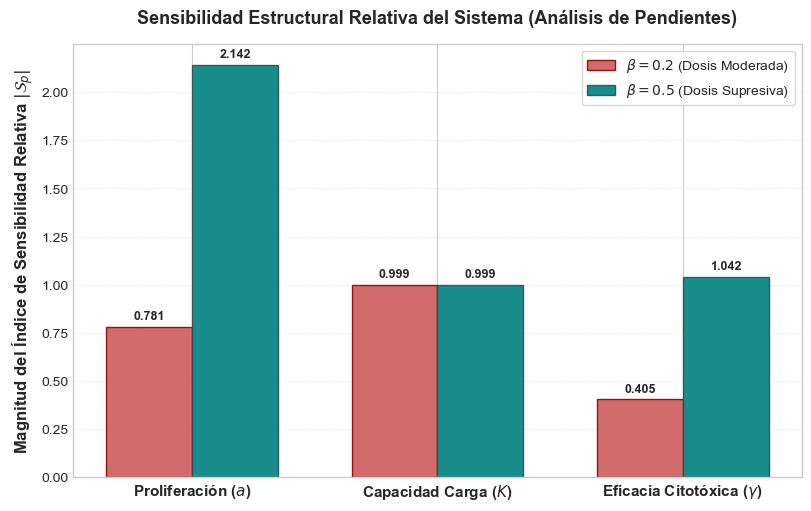

Análisis de pendientes adimensional finalizado. Gráfica exportada a: C:\Users\fatim\Desktop\TFM_Analisis_Sensibilidad\comparativa_sensibilidad_relativa.png


In [20]:
# =====================================================
# GRÁFICA 4: COMPARATIVA GLOBAL DE SENSIBILIDAD
# =====================================================
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

etiquetas = [r'Proliferación ($a$)', r'Capacidad Carga ($K$)', r'Eficacia Citotóxica ($\gamma$)']
x_pos = np.arange(len(etiquetas))
width = 0.35

# Renderizado de barras con paleta homogénea académica
b_moderada = ax.bar(x_pos - width/2, magnitud_02, width, label=r'$\beta = 0.2$ (Dosis Moderada)', 
                    color='indianred', alpha=0.9, edgecolor='darkred')
b_supresiva = ax.bar(x_pos + width/2, magnitud_05, width, label=r'$\beta = 0.5$ (Dosis Supresiva)', 
                     color='teal', alpha=0.9, edgecolor='darkslategray')

# Configuración formal de los ejes
ax.set_ylabel(r'Magnitud del Índice de Sensibilidad Relativa $|\mathcal{S}_p|$', fontsize=12, fontweight='bold')
ax.set_title('Sensibilidad Estructural Relativa del Sistema (Análisis de Pendientes)', fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.set_xticklabels(etiquetas, fontsize=11, fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.5, axis='y')
ax.legend(fontsize=10, frameon=True, loc='upper right')

# Añadir el valor cuantitativo exacto sobre cada barra
for bar in b_moderada + b_supresiva:
    yval = bar.get_height()
    ax.annotate(f'{yval:.3f}', xy=(bar.get_x() + bar.get_width()/2, yval),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')

# Guardado vectorial e impresión
ruta_guardado = os.path.join(ruta_figuras, "comparativa_sensibilidad_relativa.png")
plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
plt.show()

print(f"Análisis de pendientes adimensional finalizado. Gráfica exportada a: {ruta_guardado}")